#  Generative Adversarial Networks (GAN) — Beginner Tutorial in PyTorch

### A complete, step-by-step notebook for students

In this tutorial, we will build a **basic GAN from scratch in PyTorch**.

We will learn:

1. What a GAN is
2. The **Generator** and **Discriminator**
3. How to use a built-in dataset (**MNIST**)
4. How to create a PyTorch `DataLoader`
5. How to visualize sample images
6. How to build the Generator
7. How to build the Discriminator
8. How GAN training works
9. How to train the GAN step by step
10. How to generate new images
11. How to save and load the trained models
12. How to test the Generator
13. Common beginner mistakes and important observations

> **Goal:** By the end, students should understand the complete flow  
> **Dataset → DataLoader → Generator → Discriminator → Training → Generated Images**.

We intentionally use a **simple fully-connected GAN** rather than a more advanced DCGAN so that the core GAN idea is easy to understand.

## 1. What is a GAN?

**GAN = Generative Adversarial Network**

A GAN contains two neural networks:

### Generator (G)
The Generator starts with random noise and tries to create a realistic image.

**Random noise → Generator → Fake image**

### Discriminator (D)
The Discriminator receives an image and tries to decide whether it is:

- **Real** — from the training dataset
- **Fake** — produced by the Generator

**Image → Discriminator → Real/Fake**

### The interesting part

The two networks compete with each other:

- The **Discriminator** learns to detect fake images.
- The **Generator** learns to fool the Discriminator.

This competition can make the Generator progressively better at producing realistic-looking images.

## 2. GAN training in one simple diagram

```text
                    Random Noise
                         │
                         ▼
                  ┌─────────────┐
                  │  Generator  │
                  │     G       │
                  └──────┬──────┘
                         │
                    Fake Image
                         │
              ┌──────────┴──────────┐
              │                     │
              ▼                     ▼
        Discriminator          Discriminator
          with Fake              with Real
              │                     │
              └──────────┬──────────┘
                         ▼
                    Real / Fake
                         │
                         ▼
                    Loss + Backprop
```

### Simple intuition

Imagine:

- **Generator = student making counterfeit currency**
- **Discriminator = police officer detecting counterfeit currency**

At first, the Generator is very bad.

The Discriminator easily detects the fake images.

With training:

- Generator gets better at making fake images.
- Discriminator gets better at detecting them.
- The Generator eventually learns the patterns of the real data.

## 3. Import the required libraries

We will use:

- `torch` → deep learning
- `torchvision` → MNIST dataset and image utilities
- `matplotlib` → displaying images
- `numpy` → numerical operations
- `os` → saving generated images/models

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 4. Select CPU or GPU

PyTorch can run on:

- CPU
- NVIDIA GPU with CUDA

The following code automatically selects a GPU when CUDA is available.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


## 5. Set the main parameters

These parameters control our experiment.

### Important parameters

- `batch_size` → number of images processed at one time
- `image_size` → MNIST images are 28 × 28
- `latent_dim` → size of the random noise vector
- `num_epochs` → number of times the model sees the whole training dataset
- `lr` → learning rate



In [ ]:
# Reproducibility
torch.manual_seed(42)

# Main parameters
batch_size = 128
image_size = 28
num_channels = 1

# 28 x 28 = 784 pixels
image_dim = image_size * image_size

# Size of random noise given to the Generator
latent_dim = 100

# Training parameters
num_epochs = 20
lr = 0.0002

# Adam parameters
beta1 = 0.5
beta2 = 0.999

print("Image dimension:", image_dim)
print("Latent vector dimension:", latent_dim)

Image dimension: 784
Latent vector dimension: 100


# Part A — Loading the Dataset

## 6. Why do we need a dataset?

A GAN needs examples of **real images**.

We will use the built-in **MNIST** dataset.

MNIST contains handwritten digits:

```text
0 1 2 3 4 5 6 7 8 9
```

Each image is:

**28 × 28 pixels**

For this beginner GAN, we will ignore the digit labels.  
Why?

Because this is an **unconditional GAN**.

The Generator simply learns the overall distribution of handwritten digit images.

## 7. Image preprocessing

The original MNIST image pixels are approximately in:

```text
0 to 255
```

We convert them to tensors and normalize them to approximately:

```text
-1 to +1
```

Why?

Our Generator will use `Tanh()` at its output, whose output range is:

```text
[-1, +1]
```

Therefore, real images and generated images are represented on the same scale.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Number of training images:", len(train_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.33MB/s]

Number of training images: 60000


## 8. Create the DataLoader

A `DataLoader` gives the neural network small groups, called **batches**, instead of sending the entire dataset at once.

For example:

```text
Dataset
   ↓
DataLoader
   ↓
Batch 1 → 128 images
Batch 2 → 128 images
Batch 3 → 128 images
...
```

This is much more practical for neural-network training.

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Number of batches per epoch:", len(train_loader))

Number of batches per epoch: 469


## 9. Look at one image from the dataset

Before training a neural network, always inspect the data.

We will display one MNIST image and its tensor shape.

Image tensor shape: torch.Size([1, 28, 28])
Label: 5
Minimum pixel value: -1.0
Maximum pixel value: 1.0


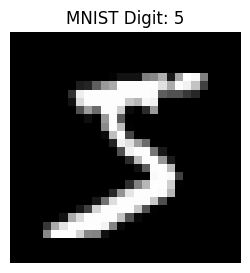

In [ ]:
image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"MNIST Digit: {label}")
plt.axis("off")
plt.show()

## 10. Display a batch of real images

Now let's see several real training images.

This is useful because students can visually understand what the GAN is trying to learn.

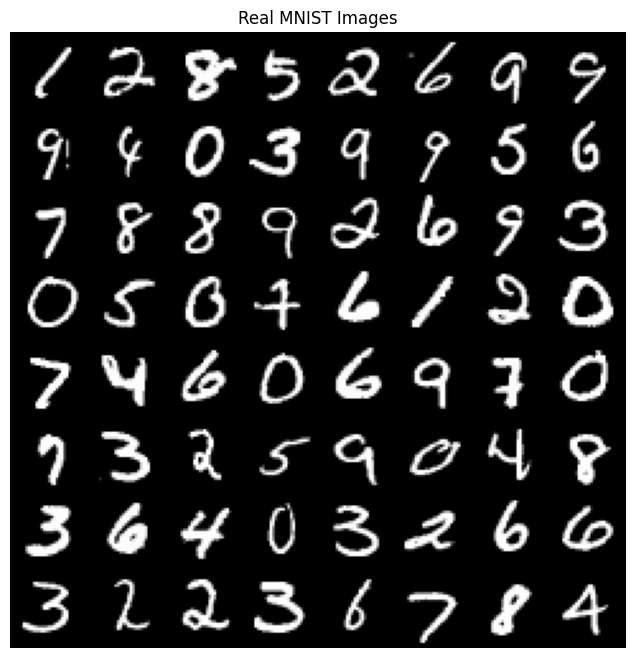

Batch image shape: torch.Size([128, 1, 28, 28])
Batch label shape: torch.Size([128])


In [ ]:
real_images, real_labels = next(iter(train_loader))

grid = make_grid(
    real_images[:64],
    nrow=8,
    normalize=True,
    padding=2
)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Real MNIST Images")
plt.axis("off")
plt.show()

print("Batch image shape:", real_images.shape)
print("Batch label shape:", real_labels.shape)

# Part B — Understanding the Generator

## 11. What does the Generator do?

The Generator receives a vector of random numbers.

For example:

```text
[0.23, -0.91, 0.45, ...]
```

This is called a **latent vector** or **noise vector**.

The Generator transforms this vector into an image.

```text
100 random numbers
       ↓
   Generator
       ↓
28 × 28 image
```

The Generator initially creates almost meaningless images.

During training, it learns how to transform noise into digit-like images.

## 12. Build the Generator

Our Generator is a simple fully-connected neural network.

Architecture:

```text
100
 ↓
256
 ↓
512
 ↓
1024
 ↓
784
 ↓
28 × 28 image
```

The final `Tanh()` produces values between **-1 and +1**.

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, image_dim=784):    ## Initialize Generator
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),    # inplace=True means the operation modifies the existing data directly

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, image_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img


generator = Generator(
    latent_dim=latent_dim,  # Noise size = 100
    image_dim=image_dim     # Image size = 784
).to(device)

print(generator)
# The Generator takes 100 random numbers and gradually transforms them into 784 pixel values, which represent a 28×28 MNIST image.

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)


## 13. Test the Generator before training

The Generator has **not learned anything yet**.

Let's give it random noise and look at the output.

We expect the images to look like random noise or meaningless patterns.

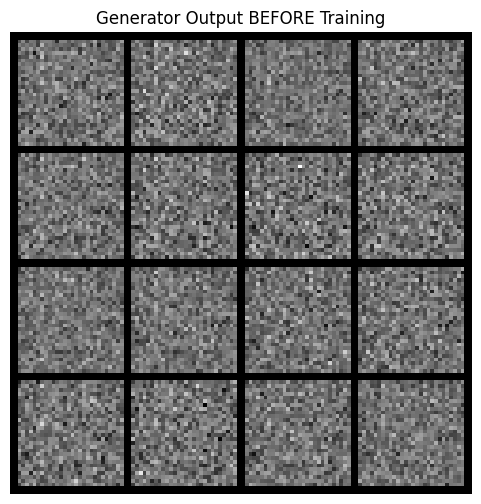

In [ ]:
z = torch.randn(16, latent_dim, device=device)

with torch.no_grad():
    fake_images = generator(z)

fake_images = fake_images.view(-1, 1, 28, 28)  # we have 128 images × 784 pixels then we want [128, 1, 28, 28] that why -1 use

grid = make_grid(fake_images, nrow=4, normalize=True, padding=2)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Generator Output BEFORE Training")
plt.axis("off")
plt.show()

# Part C — Understanding the Discriminator

## 14. What does the Discriminator do?

The Discriminator is a binary classifier.

It receives an image and produces a number representing how likely the image is real.

```text
Image
  ↓
Discriminator
  ↓
Probability / score
```

Conceptually:

```text
Real image → 1
Fake image → 0
```

The Discriminator learns from both real and generated images.

## 15. Build the Discriminator

Our Discriminator takes:

```text
28 × 28 = 784 values
```

and produces a single output.

Architecture:

```text
784
 ↓
512
 ↓
256
 ↓
1
```

We use `BCEWithLogitsLoss`, so the final layer does **not** need a Sigmoid activation.

In [ ]:
# Discriminator network
class Discriminator(nn.Module):
    # Initialize Discriminator
    def __init__(self, image_dim=784):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1)   # 1 is a score (logit)
        )


    # Forward pass
    def forward(self, img):
        img_flat = img.view(img.size(0), -1) # Flatten image
        validity = self.model(img_flat) #  # Get real/fake score
        return validity # Return score


discriminator = Discriminator(image_dim=image_dim).to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


## 16. Create the loss function

We use:

**Binary Cross Entropy with Logits Loss**

This loss is appropriate because the Discriminator performs a binary task:

```text
Real = 1
Fake = 0
```

We also use the same loss to train the Generator.

The important difference is **what the Generator is trying to achieve**:

The Generator wants the Discriminator to classify generated images as **real**.

In [ ]:
criterion = nn.BCEWithLogitsLoss()

print(criterion)

BCEWithLogitsLoss()


## 17. Create the optimizers

We need a separate optimizer for each network.

```text
Optimizer 1 → Generator
Optimizer 2 → Discriminator
```

We use Adam, which is commonly used for basic GAN implementations.

In [ ]:
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=lr,
    betas=(beta1, beta2)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=lr,
    betas=(beta1, beta2)
)

print("Generator optimizer:", optimizer_G)
print("Discriminator optimizer:", optimizer_D)

Generator optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.5, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0002
    maximize: False
    weight_decay: 0
)
Discriminator optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.5, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0002
    maximize: False
    weight_decay: 0
)


# Part D — Understanding GAN Training

## 18. The two training steps

For every batch, we perform two main steps.

### Step 1 — Train the Discriminator

Give it:

1. Real images → target `1`
2. Fake images → target `0`

The Discriminator learns to distinguish real from fake.

### Step 2 — Train the Generator

Generate fake images again.

Send them to the Discriminator.

But now the target is:

```text
1 = real
```

Why?

Because the Generator wants its fake images to be classified as real.

This is the central idea of GAN training.

## 19. One training iteration — simplified

### Discriminator

```text
Real image
   ↓
Discriminator
   ↓
Real prediction
   ↓
Compare with 1
   ↓
D loss

Fake image
   ↓
Discriminator
   ↓
Fake prediction
   ↓
Compare with 0
   ↓
D loss
```

### Generator

```text
Random noise
   ↓
Generator
   ↓
Fake image
   ↓
Discriminator
   ↓
Prediction
   ↓
Compare with 1
   ↓
G loss
```

The Generator receives gradients through the Discriminator during its update.

## 20. Train the GAN

We will now put everything together.

During training we will:

1. Load a batch of real images
2. Create random noise
3. Generate fake images
4. Train the Discriminator
5. Train the Generator
6. Record the losses
7. Periodically display generated images

> **Important:** GAN losses do not behave like ordinary classifier losses.  
> Do not expect them to simply decrease smoothly toward zero.

In [ ]:
# Fixed noise is used to monitor the same generated examples
# throughout training.
fixed_noise = torch.randn(64, latent_dim, device=device)

G_losses = []
D_losses = []

os.makedirs("gan_outputs", exist_ok=True)

print("Starting GAN training...\n")

# Repeat training for each epoch
for epoch in range(num_epochs):

    # Get one batch of real images
    for batch_idx, (real_images, _) in enumerate(train_loader):

        # Move real images to the selected device
        real_images = real_images.to(device)

        batch_size_current = real_images.size(0)  # Get current batch size

        # -------------------------------------------------
        # 1. Train Discriminator
        # -------------------------------------------------

        optimizer_D.zero_grad()  # Clear old gradients

        # Real images our taget is 1 = Real
        real_targets = torch.ones(
            batch_size_current, 1, device=device
        )

        real_output = discriminator(real_images) # Discriminator checks real images

        # Calculate loss for real images
        d_loss_real = criterion(
            real_output,
            real_targets
        )

        # Create random noise
        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_images = generator(z)

         # Create target 0 = Fake
        fake_targets = torch.zeros(
            batch_size_current, 1, device=device
        )

        # Detach() - do not send the gradient backward into the Generator. We are updating only the Discriminator.Later, when training the Generator, we do not use detach()
        # Discriminator checks fake images
        fake_output = discriminator(fake_images.detach())

         # Calculate loss for fake images
        d_loss_fake = criterion(
            fake_output,
            fake_targets
        )

        # Total Discriminator loss (Add real and fake losses)
        d_loss = d_loss_real + d_loss_fake

        d_loss.backward() # Calculate gradients
        optimizer_D.step()  # Update Discriminator weights

        # -------------------------------------------------
        # 2. Train Generator
        # -------------------------------------------------

        optimizer_G.zero_grad()

        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_images = generator(z)

        # Generator wants fake images to be classified as REAL that's why torch.one
        generator_targets = torch.ones(
            batch_size_current, 1, device=device
        )

        fake_output = discriminator(fake_images)

        # Calculate Generator los
        g_loss = criterion(
            fake_output,
            generator_targets
        )

        # Calculate Generator gradients
        g_loss.backward()  # Calculate Generator gradients
        optimizer_G.step() # Update Generator weights

        # Save losses
        G_losses.append(g_loss.item()) # Save Generator loss
        D_losses.append(d_loss.item())

    # -----------------------------------------------------
    # End of epoch: generate fixed examples
    # -----------------------------------------------------

    with torch.no_grad():
        generated = generator(fixed_noise)

    generated = generated.view(-1, 1, 28, 28) # Convert 784 pixels to 28 × 28 images

    save_image(
        generated[:64],
        f"gan_outputs/epoch_{epoch+1:03d}.png",
        nrow=8,
        normalize=True
    )

    # Print training progress
    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

print("\nTraining completed!")

Starting GAN training...

Epoch [01/20] | D Loss: 1.2322 | G Loss: 1.3972
Epoch [02/20] | D Loss: 1.1027 | G Loss: 1.6928
Epoch [03/20] | D Loss: 0.9612 | G Loss: 1.4486
Epoch [04/20] | D Loss: 0.8245 | G Loss: 1.9135
Epoch [05/20] | D Loss: 0.7805 | G Loss: 1.5318
Epoch [06/20] | D Loss: 1.7564 | G Loss: 4.1075
Epoch [07/20] | D Loss: 1.3176 | G Loss: 0.5432
Epoch [08/20] | D Loss: 0.6977 | G Loss: 2.0906
Epoch [09/20] | D Loss: 0.8075 | G Loss: 1.7245
Epoch [10/20] | D Loss: 0.9647 | G Loss: 1.7366
Epoch [11/20] | D Loss: 0.9592 | G Loss: 1.3972
Epoch [12/20] | D Loss: 0.9988 | G Loss: 2.0098
Epoch [13/20] | D Loss: 1.2795 | G Loss: 2.0893
Epoch [14/20] | D Loss: 1.3891 | G Loss: 2.4289
Epoch [15/20] | D Loss: 1.1572 | G Loss: 1.6343
Epoch [16/20] | D Loss: 1.2923 | G Loss: 0.4913
Epoch [17/20] | D Loss: 1.0701 | G Loss: 0.9990
Epoch [18/20] | D Loss: 1.1625 | G Loss: 1.1037
Epoch [19/20] | D Loss: 1.2826 | G Loss: 1.6574
Epoch [20/20] | D Loss: 1.0849 | G Loss: 0.9233

Training comp

## 21. Look at the generated images after training

Now the Generator has seen many real MNIST examples.

Let's compare its output with the untrained output.

Ideally, the generated images should now contain recognizable digit-like structures.

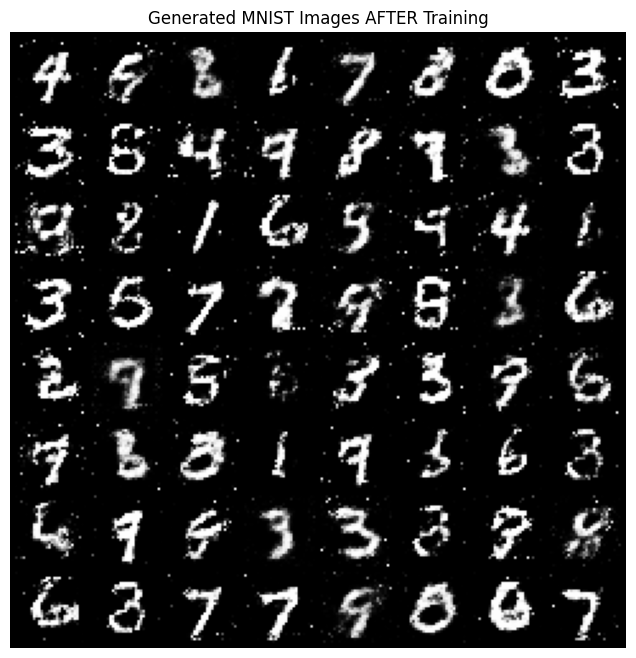

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [ ]:
generator.eval()

with torch.no_grad():
    generated_images = generator(fixed_noise)

generated_images = generated_images.view(-1, 1, 28, 28)

grid = make_grid(
    generated_images[:64],
    nrow=8,
    normalize=True,
    padding=2
)

plt.figure(figsize=(8, 8))
plt.imshow(
    grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
plt.title("Generated MNIST Images AFTER Training")
plt.axis("off")
plt.show()

generator.train()

# Part E — Understanding the Training Curves

## 22. Plot Generator and Discriminator losses

Loss curves are useful for understanding training behavior.

However, GAN losses are different from ordinary supervised learning.

A lower loss does **not automatically mean** a better GAN.

Always inspect the generated images as well.

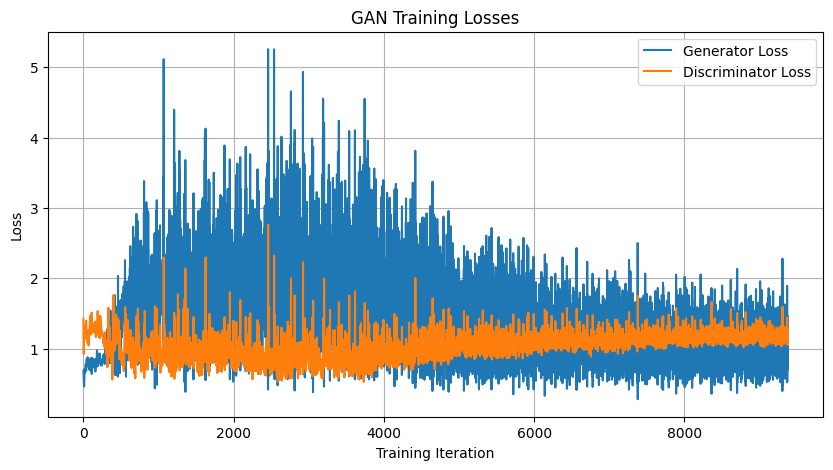

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

1. **X-axis:** Training iterations — how many times the GAN has updated its weights.

2. **Y-axis:** Loss — how much error the Generator and Discriminator are making.

3. **Blue** = Generator loss, **Orange** = Discriminator loss. The losses fluctuate because the two networks are competing with each other.
4. **Important**: Unlike normal neural networks, GAN losses do not need to continuously decrease. We mainly check whether the generated images are becoming better.

## 23. Test the Generator with completely new random noise

A useful test is to create new random latent vectors that the Generator has never seen before.

If training worked reasonably well, the Generator should still produce digit-like images.

This demonstrates that it learned a distribution rather than memorizing one fixed batch of images.

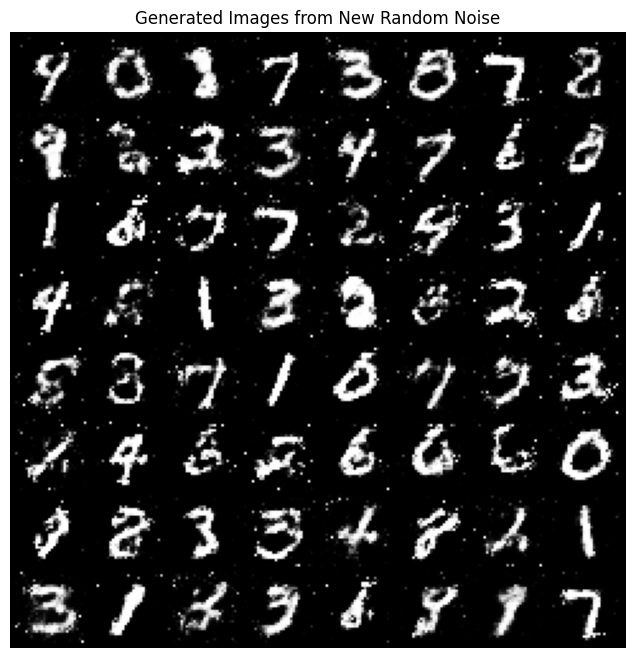

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [ ]:
generator.eval()

test_noise = torch.randn(64, latent_dim, device=device)

with torch.no_grad():
    test_generated = generator(test_noise)

test_generated = test_generated.view(-1, 1, 28, 28)

grid = make_grid(
    test_generated,
    nrow=8,
    normalize=True,
    padding=2
)

plt.figure(figsize=(8, 8))
plt.imshow(
    grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
plt.title("Generated Images from New Random Noise")
plt.axis("off")
plt.show()

generator.train()

# Part F — Saving and Loading the Models

## 24. Save the trained Generator and Discriminator

After training, we should save the learned parameters.

We use `state_dict()` for this.

In [ ]:
torch.save(
    generator.state_dict(),
    "gan_outputs/generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "gan_outputs/discriminator.pth"
)

print("Models saved successfully.")

Models saved successfully.


## 25. Load the Generator

We can create a new Generator object and load the saved weights.

This is useful when we want to generate images later without retraining the model.

In [ ]:
loaded_generator = Generator(
    latent_dim=latent_dim,
    image_dim=image_dim
).to(device)

loaded_generator.load_state_dict(
    torch.load(
        "gan_outputs/generator.pth",
        map_location=device
    )
)

loaded_generator.eval()

print("Generator loaded successfully.")

Generator loaded successfully.


## 26. Generate images using the loaded model

This is our final inference/testing step.

```text
Random noise
     ↓
Loaded Generator
     ↓
Generated image
```

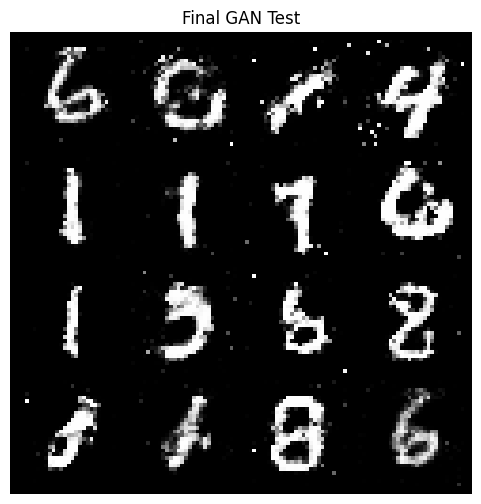

In [ ]:
new_noise = torch.randn(16, latent_dim, device=device)

with torch.no_grad():
    output = loaded_generator(new_noise)

output = output.view(-1, 1, 28, 28)

grid = make_grid(
    output,
    nrow=4,
    normalize=True,
    padding=2
)

plt.figure(figsize=(6, 6))
plt.imshow(
    grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
plt.title("Final GAN Test")
plt.axis("off")
plt.show()

# Part G — Understanding the Complete Pipeline

## 27. The complete GAN workflow

```text
                 MNIST Dataset
                       │
                       ▼
                 DataLoader
                       │
                       ▼
                Real Images
                       │
                       │
                       ▼
                Discriminator
                 ▲         │
                 │         │
                 │         ▼
Random Noise → Generator → Fake Images
                 ▲
                 │
                 └──── Generator learns
                       to fool D
```

### In every training iteration

**Discriminator:**

- Real image → target `1`
- Fake image → target `0`

**Generator:**

- Fake image → target `1`

That last point is very important.

The Generator is **not directly comparing its generated image with a real MNIST image**.

Instead, it learns through the Discriminator's feedback.

# Part H — Important Concepts for Students

## 28. What is latent space?

The Generator does not receive an image.

It receives a vector such as:

```text
z = [0.2, -0.7, 1.1, 0.4, ...]
```

This vector is called a **latent vector**.

Different random vectors can produce different generated images.

You can think of the latent vector as a hidden set of instructions that the Generator learns to convert into an image.

## 29. Why do we use `detach()`?

During the Discriminator update we have:

```python
fake_output = discriminator(fake_images.detach())
```

`detach()` tells PyTorch:

> "For this step, do not send the gradient backward into the Generator."

We are updating only the Discriminator.

Later, when training the Generator, we do **not** use `detach()`:

```python
fake_output = discriminator(fake_images)
```

Now the gradient can flow:

```text
Discriminator
     ↑
Generator
```

This allows the Generator to learn how to make images that fool the Discriminator.

## 30. Why is the Generator target `1`?

This is one of the most common beginner questions.

When training the Generator:

```python
generator_targets = torch.ones(...)
```

The generated image is fake.

But the Generator's objective is:

> Make the Discriminator believe that the fake image is real.

Therefore:

```text
Generator creates fake image
            ↓
Discriminator
            ↓
Generator wants output ≈ 1
```

This is how the Generator learns to fool the Discriminator.

# Part I — Common Beginner Questions

## 31. Does GAN training have a normal train/test split?

Not exactly like a standard classifier.

For this basic demonstration:

- MNIST training images are used to train the GAN.
- We generate **new images from new random latent vectors** to test the Generator.

The Generator is not performing ordinary classification.

For a research experiment, more rigorous evaluation should also be used, such as FID, precision/recall for generative models, or human evaluation depending on the task.

## 32. Why don't we use MNIST labels?

MNIST provides labels such as:

```text
image → 7
image → 3
image → 9
```

But our GAN is **unconditional**.

It does not receive the digit label.

Therefore:

```text
Generator(random noise)
        ↓
     any digit
```

If we wanted to tell the Generator:

> "Generate digit 7"

we could build a **Conditional GAN (cGAN)**.

## 33. What happens if training is not good?

GAN training can be unstable.

You may see:

### 1. Random/noisy images

The Generator has not learned enough.

### 2. Same digit repeatedly

This can be related to **mode collapse**.

The Generator may learn to produce only a small part of the data distribution.

### 3. Very unstable losses

GANs involve two networks competing with each other, so losses can fluctuate.

### 4. Good-looking images

The Generator has learned useful patterns from the training distribution.

# Part J — Small Classroom Experiments

## 34. Experiment 1: Change the latent dimension

Try:

```python
latent_dim = 50
```

Then compare it with:

```python
latent_dim = 100
```

Ask students:

> Does changing the size of the random vector affect the generated images?

## 35. Experiment 2: Change the learning rate

Try:

```python
lr = 0.0001
```

and then:

```python
lr = 0.0002
```

Observe:

- Training stability
- Generated image quality
- Generator loss
- Discriminator loss

## 36. Experiment 3: Train for fewer epochs

Try:

```python
num_epochs = 1
```

Then:

```python
num_epochs = 5
```

Then:

```python
num_epochs = 20
```

Compare the generated images after each experiment.

# Part K — One-Page Summary for Students

## 37. Remember these five ideas

### 1️⃣ Dataset

Real examples are required.

```text
MNIST → real images
```

### 2️⃣ Generator

Creates fake images from random noise.

```text
Noise → Generator → Fake Image
```

### 3️⃣ Discriminator

Classifies images as real or fake.

```text
Image → Discriminator → Real/Fake
```

### 4️⃣ Adversarial training

The two networks compete:

```text
Generator → tries to fool Discriminator
Discriminator → tries to detect fake images
```

### 5️⃣ Final result

The Generator learns to produce samples that resemble the training data.

```text
Random Noise
     ↓
Generator
     ↓
New MNIST-like Image
```

# 38. Final classroom takeaway

A GAN can be summarized in one sentence:

> **A Generator learns to create fake samples, while a Discriminator learns to distinguish real samples from fake samples, and their competition trains the Generator to produce increasingly realistic samples.**

### The complete PyTorch pipeline is:

```text
Import libraries
      ↓
Select CPU/GPU
      ↓
Load MNIST
      ↓
Create DataLoader
      ↓
Visualize real images
      ↓
Build Generator
      ↓
Build Discriminator
      ↓
Define loss
      ↓
Define optimizers
      ↓
Train Discriminator
      ↓
Train Generator
      ↓
Repeat for many epochs
      ↓
Visualize generated images
      ↓
Save model
      ↓
Load model
      ↓
Generate new images
```

🎉 **You have now built a basic GAN from scratch in PyTorch!**